In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density
from tqdm.auto import tqdm
import sisl
from ase.visualize import view

import ipywidgets as widgets
from ipywidgets import interact, Dropdown, fixed, IntSlider
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [211]:
N0 = N1 = 8
ETA = 1e-3
NK1 = 250
DELTA_E = 0.1
EMAX = 0.
EMIN = -EMAX
ENERGIES = np.arange(EMAX, EMIN-DELTA_E/2, -DELTA_E)[::-1]; print(ENERGIES)

[0.]


In [212]:
# gr = sisl.geom.graphene()
# gr = gr.tile(N0,0).tile(N1,1)
# print(gr.lattice)
# # gr = gr.untile(N0,0).untile(N1,1)
# # view(gr.to.ase())
# gr.plot(axes="xy")

In [213]:
# a = 1.43
# theta = 2*np.pi/3
# phis = theta/2
# b = a*np.sin(np.pi/3)
# kind = "armchair"
# if kind.lower() == 'armchair':       
#     lat = np.array([[3*a,  0.,     0.],
#                     [0.,        2*b,   0.],
#                     [0.,        0.,     20.]])
# elif kind.lower() == 'zigzag':
#     lat = np.array([[2*b,  0.,         0.], # 
#                     [0.,    3*a,   0.],
#                     [0.,    0.,         20.]])

In [214]:
# gr = sisl.geom.graphene_nanoribbon(width=2, bond=a, kind=kind)
# gr = gr.translate([0, -10, 0]) # vacuum 20 gives 10 Å vacuum in both directions
    
# print(f"kind : {kind}")
# print(f"cell height: {gr.cell[1,1]}")
# # print(f"estimate of height {gr.cell[1,1]}: ")
# print(f"zig-zag: {20 + (3-1)*a},\t armchair: {20 + (2-1)*b}")
# print()
# print(f"cell length: {gr.cell[0,0]}")
# print(f"zig-zag: {2*b},\t armchair: {3*a}")
# gr.set_nsc([3,3,1])
# # view(gr.to.ase())
# gr.plot(axes="xy")


In [215]:
# gr = sisl.geom.graphene_nanoribbon(width=2, bond=a, kind=kind)
# gr = gr.translate([0, -10, 0]) # vacuum 20 gives 10 Å vacuum in both directions

# gr.set_lattice(lat)
# gr = gr.tile(2, 0).tile(5,1)
# print(f"kind : {kind}")
# print(f"cell height: {gr.cell[1,1]}")
# # print(f"estimate of height {gr.cell[1,1]}: ")
# print(f"zig-zag: {N1*3*a},\t armchair: {N1*2*b}")
# print()
# print(f"cell length: {gr.cell[0,0]}")
# print(f"zig-zag: {N0*2*b},\t armchair: {N0*3*a}")
# # print(f"estimate of width ({gr.cell[1,1]}): {2*b}, {3*a}")
# print(gr.na, N0*N1*4)
# gr.plot(axes="xy")

In [308]:
def make_device(bond=1.43, kind="armchair"):
    gr = sisl.geom.graphene(bond=bond, atoms="C", orthogonal=True) # returns *orthogonal* unitcell instead of primitive
    if kind == "armchair":
        return gr
    elif kind == "zigzag":
        gr = gr.rotate([180, [0,1,0]]).rotate([-90, [0,0,1]])
        xyz = gr.xyz.round(6)
        cell = gr.cell
        cell = np.where(np.isclose(cell, 0), 0, cell) # convert -0.0 rounding error to 0.0
        
        atom_sort_idx = np.lexsort((xyz[:, 1], xyz[:, 0]))
        vector_sort_idx = np.lexsort((-cell[:, 2], -cell[:, 1], -cell[:, 0]))
        # gr.set_lattice(cell[vector_sort_idx, :])
        gr.set_nsc([3,3,1])
        gr.sub(atom_sort_idx)
        return gr

In [309]:
def plot_with_index(geometry):
    
    x,y,z = geometry.xyz.T
    cell = geometry.cell
    fig, ax = plt.subplots(1,1,figsize=(8,6))
    
    ax.scatter(x,y, marker='o', s=100, color='grey')
    
    for i in range(0, geometry.na):
        ax.annotate(text=i, xy=(x[i], y[i]), xytext=(x[i]+0.1, y[i]+0.1))
    ax.axes.set_aspect("equal")
    boxx, boxy = np.array([
        [0,     0,                  cell[:,0].max(),    cell[:,0].max(),    0],
        [0,     cell[:, 1].max(),   cell[:, 1].max(),   0,                  0]])
    ax.plot(boxx, boxy, color="green")
    
    xmax = np.max(geometry.cell[:, 0])
    ymax = np.max(geometry.cell[:, 1])
    ylim = (-1, ymax+1)
    xlim = (-1, xmax+1)
    ax.set(ylim=ylim, xlim=xlim, 
           xlabel="x",
           ylabel="y")

[[-8.88178420e-16  4.29000000e+00 -5.25373477e-16]
 [ 2.47683265e+00  4.44089210e-16  0.00000000e+00]
 [ 3.94430453e-31 -2.44929360e-15 -2.00000000e+01]]


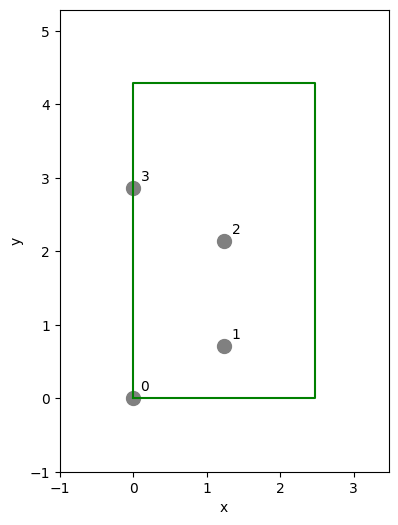

In [310]:
gr = make_device(kind="zigzag")
print(gr.cell)
# view(gr.to.ase())
# geomNN = gr.tile(2,0).tile(5,1)
plot_with_index(gr)

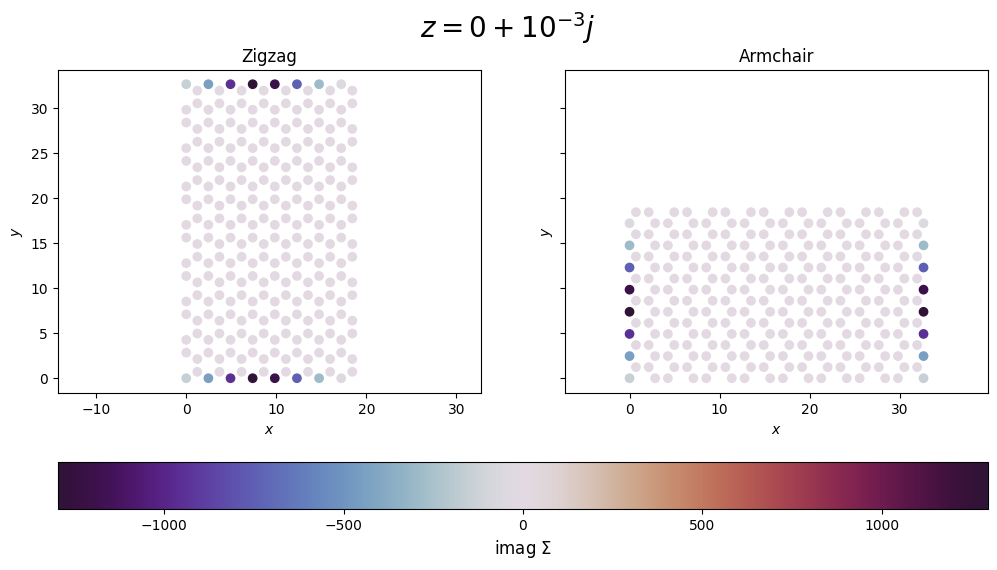

In [315]:
a = 1.42
fig, axes = plt.subplots(1,2,figsize=(12,6), sharey=True)
for i, kind in enumerate(["zigzag", "armchair"]):
    gr = make_device(bond=a, kind=kind)
    Ham0 = sisl.Hamiltonian(gr)
    Ham0.set_nsc([3,3,1]) # needed for nanoribbon
    r = (0.1, a+1e-1)
    t = (0.0, -2.7)
    Ham0.construct([r, t])

    rse = sisl.RealSpaceSE(Ham0,  0, 1, (N1, N0, 1))
    rse.setup(eta=ETA,
            bz=sisl.MonkhorstPack(Ham0, [1, NK1, 1]))
    elec_ham, elec_idx = rse.real_space_coupling(ret_indices=True)
    
    HamNN = Ham0.tile(N0,0).tile(N1,1)
    all_atoms = np.arange(0, HamNN.na)
    inside_aotms = np.delete(all_atoms, elec_idx)
    alist = np.concatenate([elec_idx, inside_aotms])
    Ham_sub = HamNN.sub(alist)
    Ham_sub.reduce()
    RSE = rse.self_energy(0 + ETA*1j)
    RSE_sub = RSE[alist,:][:,alist]

    # --- plotting ---
    part = "imag"
    use_sub = True


    if use_sub:
        x,y,z = Ham_sub.xyz.T
        rse_diag = np.diagonal(RSE_sub).copy()
    else:
        x,y,z = HamNN.xyz.T
        rse_diag = np.diagonal(RSE).copy()
    
    
        

    if part == "imag": rse_diag = np.imag(rse_diag)
    else: rse_diag = np.real(rse_diag)
    vmax = np.abs(rse_diag).max()
    vmin = -vmax
    sc = axes[i].scatter(x, y, c=rse_diag, vmin=vmin, vmax=vmax, cmap="twilight_shifted")
    axes[i].set(xlabel=r"$x$",
                ylabel=r"$y$",
                title=f"{kind.capitalize()}")

    axes[i].axis("equal")

fig.suptitle(rf"$z = 0 + 10^{{{np.log10(ETA):.0f}}}j$", size=20)
cbar = fig.colorbar(sc, ax=axes, location="bottom", orientation="horizontal", pad=0.15)
cbar.set_label(rf"{part} $\Sigma$", size=12)
# fig.tight_layout()
fig.canvas.draw()


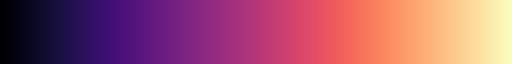

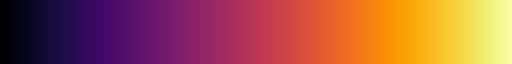

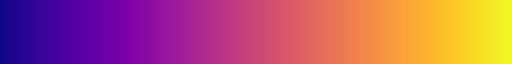

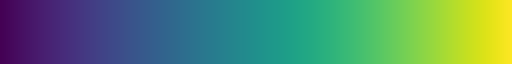

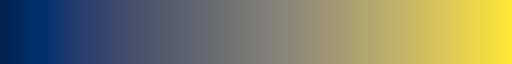

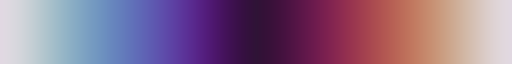

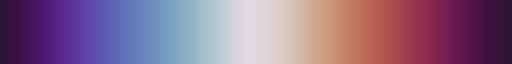

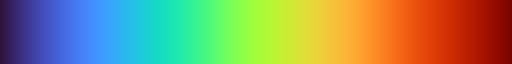

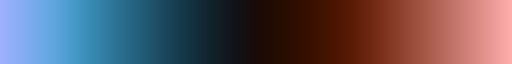

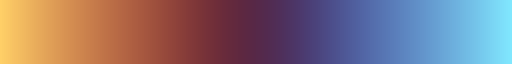

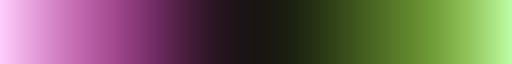

In [207]:
from matplotlib.cm import cmaps_listed
for key in cmaps_listed.keys():
    display(cmaps_listed[key])